# VGG16 Image Classifier — Alzheimer's MRI Classification

Transfer learning with pre-trained VGG16 on the Alzheimer's MRI dataset (4 classes).  
Includes data augmentation, proper normalization, phase-1 head training, phase-2 fine-tuning of the last conv block, EarlyStopping, training curves, and a reusable prediction function.

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array

# Image dimensions
IMG_WIDTH, IMG_HEIGHT = 150, 150

# Training parameters
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15   # Head-only training
EPOCHS_PHASE2 = 10   # Fine-tuning last conv block

In [25]:
# # Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Step 0: Clean previous extraction (avoid overwrite prompt)
!rm -rf /content/data
!rm -rf /content/AugmentedAlzheimerDataset

# Step 1: Unzip properly (force overwrite, no prompt)
!unzip -oq /content/dataset.zip -d /content/

print("Unzip done ✅")

# Step 2: Check structure
import os

print("\nContent folder:")
print(os.listdir("/content"))

# Step 3: FIXED PATH (based on your screenshot)
DATASET_PATH = "/content/data/AugmentedAlzheimerDataset"

# Step 4: Verify
print("\nDataset path:", DATASET_PATH)
print("\nClasses inside dataset:")
print(os.listdir(DATASET_PATH))

Unzip done ✅

Content folder:
['.config', 'data', 'dataset.zip', 'vgg16_alzheimers_classifier.keras', 'training_curves.png', 'drive', 'sample_data']

Dataset path: /content/data/AugmentedAlzheimerDataset

Classes inside dataset:
['MildDemented', 'ModerateDemented', 'VeryMildDemented', 'NonDemented']


In [27]:
class_names = sorted(os.listdir(DATASET_PATH))
print(class_names)

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


## Data Loading & Preprocessing

Loads Alzheimer's MRI Dataset from local Colab storage using `image_dataset_from_directory`.

**Folder structure:**
```
AugmentedAlzheimerDataset/
├── NonDemented/
├── VeryMildDemented/
├── MildDemented/
└── ModerateDemented/
```

**Split:** 70% Train / 15% Validation / 15% Test  
**Classes:** NonDemented, VeryMildDemented, MildDemented, ModerateDemented (4 classes)

In [28]:
# Dataset path mapped to WSL (Windows E: drive maps to /mnt/e/)
# Dataset path for Windows (Antigravity environment)
DATA_DIR = "/content/data/AugmentedAlzheimerDataset"

print("Loading Alzheimer's MRI dataset...")
print(f"Data directory: {DATA_DIR}")
print(os.listdir(DATA_DIR))

try:
    # ── Load training split (70%) ──
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        image_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        validation_split=0.30,   # hold out 30% for val + test
        subset='training',
        seed=42
    )

    # ── Load holdout split (30%) — will be split 50/50 into val and test ──
    holdout_dataset = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        image_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        validation_split=0.30,
        subset='validation',
        seed=42
    )

    # ── Split holdout 50/50 into val (15%) and test (15%) ──
    holdout_batches = len(holdout_dataset)
    val_batches     = holdout_batches // 2

    val_dataset  = holdout_dataset.take(val_batches)
    test_dataset = holdout_dataset.skip(val_batches)

    # Class names detected from folder names
    class_names = train_dataset.class_names
    num_classes = len(class_names)
    print(f"Classes found     : {class_names}")

    # ── Prefetch datasets (Normalization and Augmentation moved to model logic) ──
    train_ds = train_dataset.prefetch(tf.data.AUTOTUNE)
    val_ds = val_dataset.prefetch(tf.data.AUTOTUNE)
    test_ds = test_dataset.prefetch(tf.data.AUTOTUNE)

    train_samples = len(train_dataset) * BATCH_SIZE
    val_samples   = len(val_dataset)   * BATCH_SIZE
    test_samples  = len(test_dataset)  * BATCH_SIZE

    print(f"Training batches  : {len(train_dataset)}  (~{train_samples} images)")
    print(f"Validation batches: {len(val_dataset)}  (~{val_samples} images)")
    print(f"Test batches      : {len(test_dataset)}  (~{test_samples} images)")
    print("Dataset loaded successfully!")

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("\nMake sure the dataset was copied correctly and contains NonDemented/, VeryMildDemented/, MildDemented/, and ModerateDemented/ subfolders.")

Loading Alzheimer's MRI dataset...
Data directory: /content/data/AugmentedAlzheimerDataset
['MildDemented', 'ModerateDemented', 'VeryMildDemented', 'NonDemented']
Found 33984 files belonging to 4 classes.
Using 23789 files for training.
Found 33984 files belonging to 4 classes.
Using 10195 files for validation.
Classes found     : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Training batches  : 744  (~23808 images)
Validation batches: 159  (~5088 images)
Test batches      : 160  (~5120 images)
Dataset loaded successfully!


## Model — VGG16 Transfer Learning

Load VGG16 with ImageNet weights, freeze all base layers, attach a custom classification head using `GlobalAveragePooling2D` (fewer params, better generalization than `Flatten`).

Training is split into two phases:
- **Phase 1**: Train only the custom head (base fully frozen)
- **Phase 2**: Unfreeze the last conv block (`block5`) and fine-tune at a lower learning rate

In [29]:
# ✅ 1. Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# ✅ 3. Build Model with Augmentation
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.vgg16.preprocess_input(x)
x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# ✅ 4. Compile (with label smoothing)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# ✅ 5. Class Weights (handle imbalance)
class_weight = {
    0: 1.0,
    1: 1.5,
    2: 1.5,
    3: 2.0
}

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 150, 150,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 150, 150)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 150, 150)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 150, 150)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 150, 150,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 150, 150,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 4, 4, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Phase 1 — Train Custom Head

EarlyStopping monitors `val_loss` and stops if it doesn't improve for 3 epochs, restoring the best weights automatically.

In [30]:
# ✅ 6. Train Phase 1
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 72s 94ms/step - accuracy: 0.3478 - loss: 4.0599 - val_accuracy: 0.4851 - val_loss: 1.2266
Epoch 2/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.4245 - loss: 1.9075 - val_accuracy: 0.5206 - val_loss: 1.1291
Epoch 3/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.4664 - loss: 1.7657 - val_accuracy: 0.5470 - val_loss: 1.0797
Epoch 4/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.4995 - loss: 1.6840 - val_accuracy: 0.5822 - val_loss: 1.0354
Epoch 5/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.5206 - loss: 1.6347 - val_accuracy: 0.6012 - val_loss: 1.0100
Epoch 6/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.5396 - loss: 1.5966 - val_accuracy: 0.6272 - val_loss: 0.9834
Epoch 7/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.5567 - loss: 1.5676 - val_accuracy: 0.6362 - val_loss: 0.9679
Epoch 8/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.5682 - loss: 1.5400 - 

## Phase 2 — Fine-Tune Last Conv Block (block5)

Unfreeze VGG16's last convolutional block (`block5_conv1`, `block5_conv2`, `block5_conv3`) and train at a much lower learning rate (`1e-5`).  
This lets the model adapt the high-level ImageNet features to MRI-specific patterns without destroying the earlier layers.

> **Expected gain:** +2–5% val accuracy over phase 1 alone.

In [31]:
# ✅ 7. Fine-Tuning (Unfreeze last layers)
base_model.trainable = True

for layer in base_model.layers[:-8]:
    layer.trainable = False

# ✅ 8. Recompile with lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# ✅ 9. Train Phase 2
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=[early_stop]
)

# Save final model
model.save('vgg16_alzheimers_classifier.keras')
print("\nModel saved as 'vgg16_alzheimers_classifier.keras'")

Epoch 1/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 118s 155ms/step - accuracy: 0.6627 - loss: 1.3628 - val_accuracy: 0.7535 - val_loss: 0.8012
Epoch 2/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 115s 154ms/step - accuracy: 0.7383 - loss: 1.2207 - val_accuracy: 0.8129 - val_loss: 0.7140
Epoch 3/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 115s 154ms/step - accuracy: 0.7882 - loss: 1.1104 - val_accuracy: 0.8084 - val_loss: 0.7112
Epoch 4/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 115s 154ms/step - accuracy: 0.8371 - loss: 1.0185 - val_accuracy: 0.8984 - val_loss: 0.5776
Epoch 5/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 115s 154ms/step - accuracy: 0.8747 - loss: 0.9360 - val_accuracy: 0.9216 - val_loss: 0.5422
Epoch 6/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 115s 155ms/step - accuracy: 0.9032 - loss: 0.8727 - val_accuracy: 0.9389 - val_loss: 0.5145
Epoch 7/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 115s 154ms/step - accuracy: 0.9282 - loss: 0.8172 - val_accuracy: 0.9302 - val_loss: 0.5140
Epoch 8/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 115s 154ms/step - accuracy: 0.9480 -

## Final Evaluation on Test Set

Evaluate the trained model on the **held-out test set** (15% of data, never seen during training or validation).  
This gives an unbiased measure of how well the model generalizes to new MRI images.

In [32]:
if 'test_ds' in locals():
    print("Evaluating on test set (unseen data)...\n")
    test_loss, test_acc = model.evaluate(test_ds, verbose=1)
    print(f"\n=== Final Test Results ===")
    print(f"Test Accuracy : {test_acc * 100:.2f}%")
    print(f"Test Loss     : {test_loss:.4f}")
else:
    print("Test dataset not found. Run the data loading cell first.")

Evaluating on test set (unseen data)...

160/160 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9789 - loss: 0.4330

=== Final Test Results ===
Test Accuracy : 97.89%
Test Loss     : 0.4330


## Training Curves

Plot accuracy and loss for both phases to diagnose overfitting or underfitting.

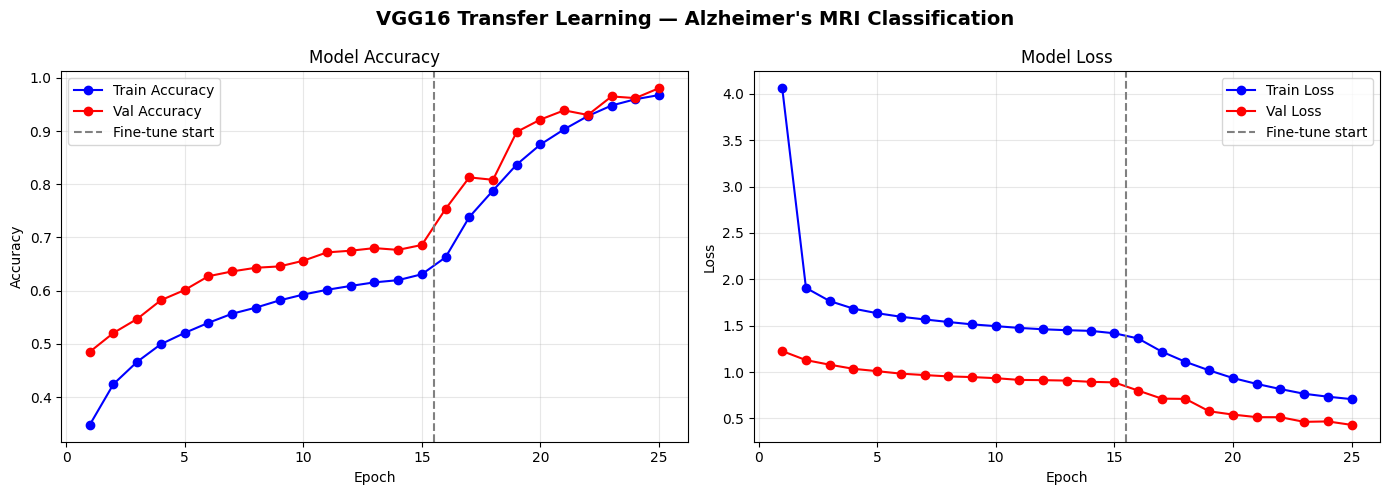

Training curves saved as 'training_curves.png'


In [33]:
if 'history_p1' in locals():
    # Combine phase 1 and phase 2 histories (if phase 2 ran)
    acc     = history_p1.history['accuracy']
    val_acc = history_p1.history['val_accuracy']
    loss    = history_p1.history['loss']
    val_loss= history_p1.history['val_loss']
    p1_len  = len(acc)

    if 'history_p2' in locals():
        acc      += history_p2.history['accuracy']
        val_acc  += history_p2.history['val_accuracy']
        loss     += history_p2.history['loss']
        val_loss += history_p2.history['val_loss']

    epochs_ran = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("VGG16 Transfer Learning — Alzheimer's MRI Classification", fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs_ran, acc,     'b-o', label='Train Accuracy')
    axes[0].plot(epochs_ran, val_acc, 'r-o', label='Val Accuracy')
    if 'history_p2' in locals():
        axes[0].axvline(x=p1_len + 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_ran, loss,     'b-o', label='Train Loss')
    axes[1].plot(epochs_ran, val_loss, 'r-o', label='Val Loss')
    if 'history_p2' in locals():
        axes[1].axvline(x=p1_len + 0.5, color='gray', linestyle='--', label='Fine-tune start')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Training curves saved as 'training_curves.png'")
else:
    print("No training history found. Run the training cells first.")

## Prediction on New MRI Image

Load any Alzheimer's MRI image and get a prediction with confidence score.


Processing: /content/1.jpg
Class probabilities:
  MildDemented             8.8%  ██
  ModerateDemented         5.1%  █
  NonDemented             32.4%  █████████
  VeryMildDemented        53.7%  ████████████████


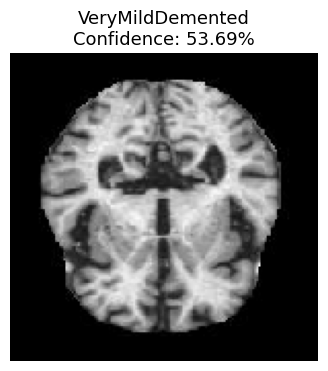


Predicted : VeryMildDemented
Confidence: 53.69%

Processing: /content/2.jpg
Class probabilities:
  MildDemented            62.8%  ██████████████████
  ModerateDemented         2.3%  
  NonDemented             13.5%  ████
  VeryMildDemented        21.4%  ██████


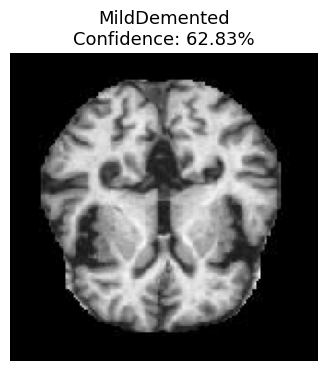


Predicted : MildDemented
Confidence: 62.83%

Processing: /content/3.jpg
Class probabilities:
  MildDemented             4.7%  █
  ModerateDemented         3.0%  
  NonDemented             81.9%  ████████████████████████
  VeryMildDemented        10.4%  ███


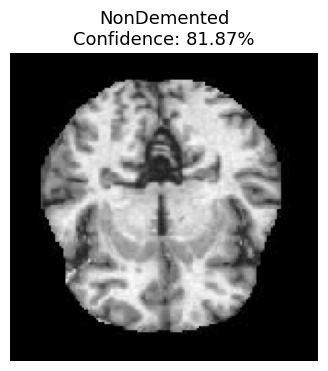


Predicted : NonDemented
Confidence: 81.87%

Processing: /content/4.jpg
Class probabilities:
  MildDemented            15.7%  ████
  ModerateDemented        48.8%  ██████████████
  NonDemented             24.9%  ███████
  VeryMildDemented        10.6%  ███


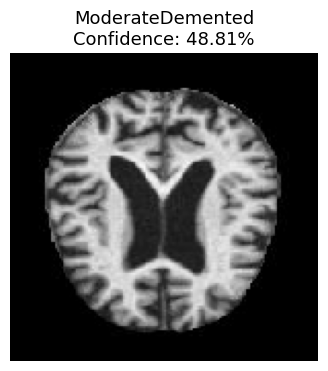


Predicted : ModerateDemented
Confidence: 48.81%

Processing: /content/5.jpg
Class probabilities:
  MildDemented            70.5%  █████████████████████
  ModerateDemented         2.4%  
  NonDemented              7.1%  ██
  VeryMildDemented        20.0%  █████


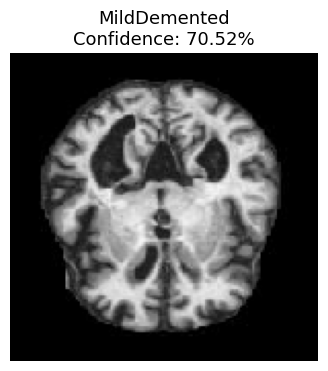


Predicted : MildDemented
Confidence: 70.52%

Processing: /content/6.jpg
Class probabilities:
  MildDemented            17.5%  █████
  ModerateDemented         5.8%  █
  NonDemented             48.5%  ██████████████
  VeryMildDemented        28.1%  ████████


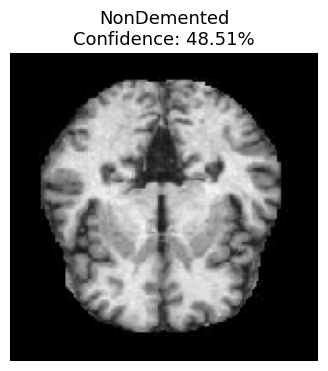


Predicted : NonDemented
Confidence: 48.51%

Processing: /content/7.jpg
Class probabilities:
  MildDemented            12.1%  ███
  ModerateDemented        36.2%  ██████████
  NonDemented              6.7%  ██
  VeryMildDemented        45.0%  █████████████


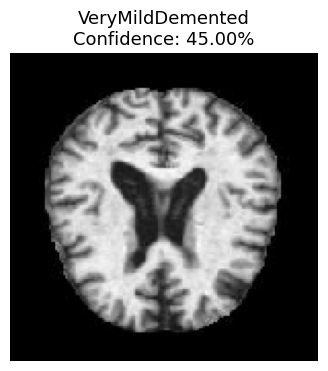


Predicted : VeryMildDemented
Confidence: 45.00%

Processing: /content/8.jpg
Class probabilities:
  MildDemented             7.2%  ██
  ModerateDemented         3.1%  
  NonDemented             10.4%  ███
  VeryMildDemented        79.3%  ███████████████████████


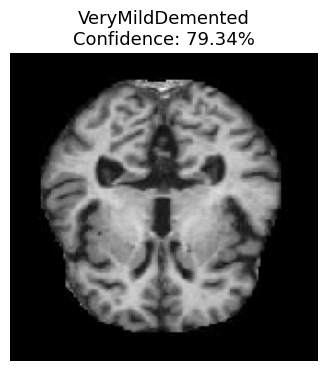


Predicted : VeryMildDemented
Confidence: 79.34%

Processing: /content/9.jpg
Class probabilities:
  MildDemented             5.1%  █
  ModerateDemented        55.8%  ████████████████
  NonDemented             23.5%  ███████
  VeryMildDemented        15.5%  ████


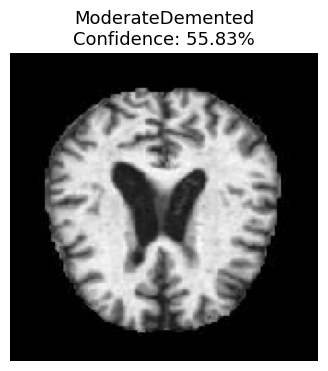


Predicted : ModerateDemented
Confidence: 55.83%

Processing: /content/10.jpg
Class probabilities:
  MildDemented            47.6%  ██████████████
  ModerateDemented         6.2%  █
  NonDemented             42.8%  ████████████
  VeryMildDemented         3.3%  █


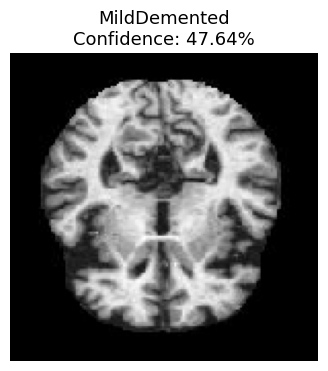


Predicted : MildDemented
Confidence: 47.64%

Processing: /content/11.jpg
Class probabilities:
  MildDemented             3.6%  █
  ModerateDemented         1.7%  
  NonDemented              8.4%  ██
  VeryMildDemented        86.4%  █████████████████████████


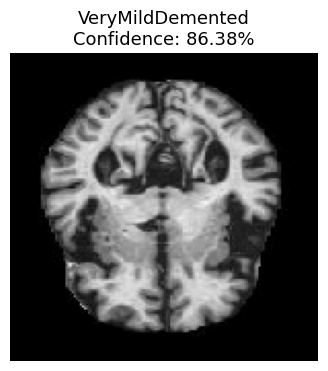


Predicted : VeryMildDemented
Confidence: 86.38%

Processing: /content/12.jpg
Class probabilities:
  MildDemented             1.4%  
  ModerateDemented         2.2%  
  NonDemented             93.8%  ████████████████████████████
  VeryMildDemented         2.5%  


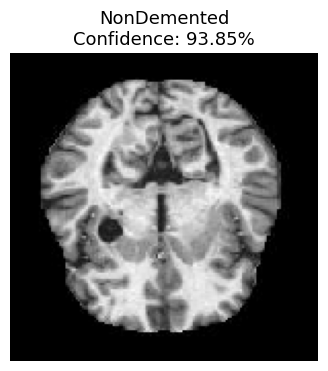


Predicted : NonDemented
Confidence: 93.85%

Processing: /content/13.jpg
Class probabilities:
  MildDemented            84.1%  █████████████████████████
  ModerateDemented         3.1%  
  NonDemented              9.8%  ██
  VeryMildDemented         3.0%  


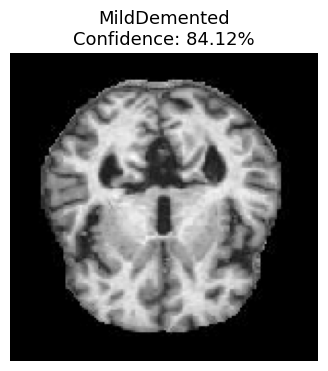


Predicted : MildDemented
Confidence: 84.12%

Processing: /content/14.jpg
Class probabilities:
  MildDemented             2.0%  
  ModerateDemented         2.1%  
  NonDemented              5.1%  █
  VeryMildDemented        90.8%  ███████████████████████████


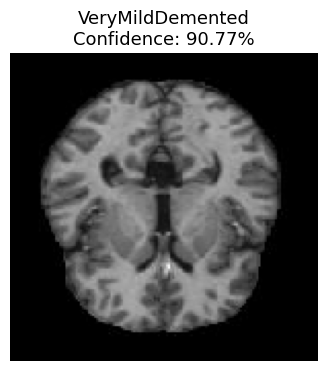


Predicted : VeryMildDemented
Confidence: 90.77%

Processing: /content/15.jpg
Class probabilities:
  MildDemented            52.6%  ███████████████
  ModerateDemented         3.7%  █
  NonDemented             30.7%  █████████
  VeryMildDemented        12.9%  ███


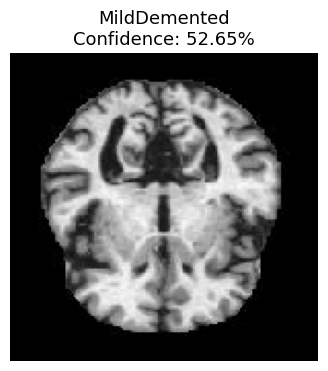


Predicted : MildDemented
Confidence: 52.65%

Processing: /content/16.jpg
Class probabilities:
  MildDemented             2.0%  
  ModerateDemented         1.2%  
  NonDemented             91.2%  ███████████████████████████
  VeryMildDemented         5.6%  █


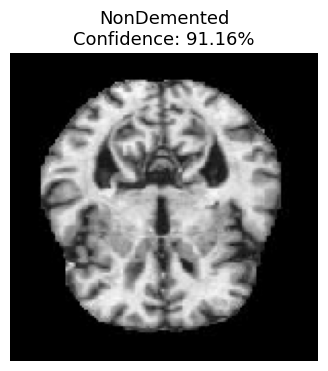


Predicted : NonDemented
Confidence: 91.16%

Processing: /content/17.jpg
Class probabilities:
  MildDemented            12.6%  ███
  ModerateDemented        69.1%  ████████████████████
  NonDemented             11.4%  ███
  VeryMildDemented         6.8%  ██


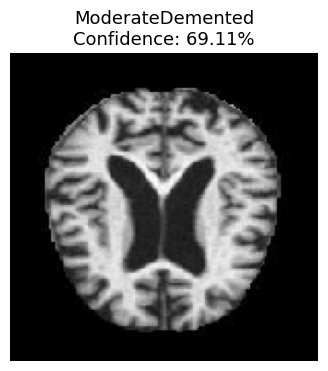


Predicted : ModerateDemented
Confidence: 69.11%

Processing: /content/18.jpg
Class probabilities:
  MildDemented             0.7%  
  ModerateDemented         1.1%  
  NonDemented             97.0%  █████████████████████████████
  VeryMildDemented         1.1%  


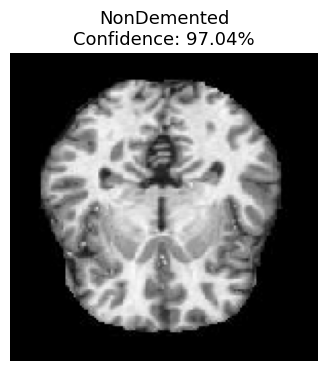


Predicted : NonDemented
Confidence: 97.04%

Processing: /content/19.jpg
Class probabilities:
  MildDemented            53.6%  ████████████████
  ModerateDemented         5.7%  █
  NonDemented             23.1%  ██████
  VeryMildDemented        17.7%  █████


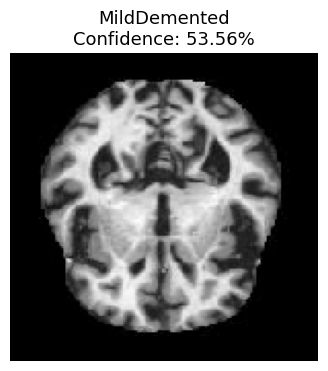


Predicted : MildDemented
Confidence: 53.56%

Processing: /content/20.jpg
Class probabilities:
  MildDemented            83.4%  █████████████████████████
  ModerateDemented         0.9%  
  NonDemented              1.6%  
  VeryMildDemented        14.1%  ████


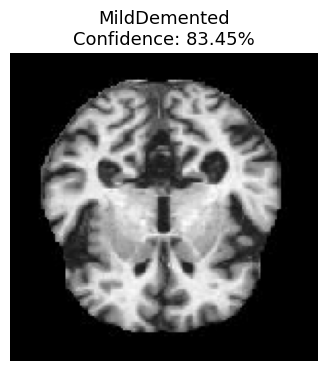


Predicted : MildDemented
Confidence: 83.45%


In [35]:
def predict_image(model, image_path, class_names=None):
    """Predict Alzheimer's classification for a given MRI image path."""
    if not os.path.exists(image_path):
        print(f"Error: Image not found at '{image_path}'")
        return

    # Default class labels for Alzheimer's
    if class_names is None:
        class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

    img = load_img(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = img_to_array(img)
    # Normalize to [0,1] — matches the training pipeline
    img_array = np.expand_dims(img_array, axis=0) # Preprocessing is handled inside the model

    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence    = predictions[0][predicted_idx]

    # Show all class probabilities
    print("Class probabilities:")
    for name, prob in zip(class_names, predictions[0]):
        bar = '█' * int(prob * 30)
        print(f"  {name:<22} {prob*100:5.1f}%  {bar}")

    # Show image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT)))
    plt.title(f"{class_names[predicted_idx]}\nConfidence: {confidence*100:.2f}%", fontsize=13)
    plt.axis('off')
    plt.show()

    print(f"\nPredicted : {class_names[predicted_idx]}")
    print(f"Confidence: {confidence * 100:.2f}%")

# --- Usage ---
folder_path = "/content"  # change if your images are in a different folder

for i in range(1, 21):
    img_path = os.path.join(folder_path, f"{i}.jpg")
    print(f"\nProcessing: {img_path}")
    predict_image(model, img_path, class_names)

In [36]:
model.save("/content/alzheimer_model.h5")

In [37]:
from google.colab import files
files.download("/content/alzheimer_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

160/160 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.9790 - loss: 0.4331
Test Accuracy: 97.90%
